# 3D — Rigor: o que sobrevive estatisticamente?

**Pergunta respondida:** *quais das relações defasadas do 3C sobrevivem quando se corrige a autocorrelação das séries (graus de liberdade efetivos), a multiplicidade de testes (FDR) e se exige intervalo de confiança que exclua zero?*

**Metodologia.**
1. Para **cada** par (variável, lag) do 3C: `N_eff` por autocorrelação lag-1 (Bretherton), p-valor do teste-t com `N_eff`, e IC95 por transformação Fisher-z — implementações de `nino_brasil.stats.significance`.
2. **FDR Benjamini–Hochberg (α=0,05)** aplicado sobre a família completa de testes (13 variáveis × 79 lags = 1.027 testes) — controla descobertas falsas da varredura de lags.
3. Sobrevivente = FDR-significativo **e** IC95 que exclui zero. O melhor lag reportado é o de maior |r| entre os sobreviventes daquela variável.
4. O mesmo filtro FDR é aplicado ao mapa lon×lag do 3C (família própria).

**Saídas:** `phase3D_testes_completos.csv`, `phase3D_ranking_significativo.csv`, forest plot (IC95) e mapa lon×lag mascarado por FDR.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u
from nino_brasil.stats.significance import effective_sample_size, correlation_p_value, benjamini_hochberg_fdr

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
COMMON = '1993-01-01'
w = weekly.loc[COMMON:]
target = w['nino34_ssta']
predictors = [c for c in w.columns if c != 'nino34_ssta']
LAGS = range(0, 79)

rows = []
for col in predictors:
    for lag in LAGS:
        x = w[col].shift(lag)
        m = x.notna() & target.notna()
        if m.sum() < 100: continue
        r = float(np.corrcoef(x[m], target[m])[0,1])
        neff = effective_sample_size(x[m].values, target[m].values)
        p = correlation_p_value(r, neff)
        z = np.arctanh(np.clip(r, -0.999999, 0.999999)); se = 1/np.sqrt(max(neff-3, 1))
        rows.append({'variavel': col, 'lag_semanas': lag, 'r': r, 'n': int(m.sum()),
                     'n_eff': round(float(neff),1), 'p_efetivo': p,
                     'ic95_low': float(np.tanh(z-1.96*se)), 'ic95_high': float(np.tanh(z+1.96*se))})
tests = pd.DataFrame(rows)
rej, qvals = benjamini_hochberg_fdr(tests['p_efetivo'].values, alpha=0.05)
tests['fdr_significativo'] = rej
tests['q_valor'] = qvals
pcrit = float(tests.loc[tests['fdr_significativo'], 'p_efetivo'].max()) if rej.any() else float('nan')
tests['sobrevive'] = tests['fdr_significativo'] & ((tests['ic95_low'] > 0) | (tests['ic95_high'] < 0))
tests.round(4).to_csv(u.STATS / 'phase3D_testes_completos.csv', index=False)
print(f'[tabela] phase3D_testes_completos.csv | testes={len(tests)} | p_critico_FDR={pcrit:.4g} | sobreviventes={int(tests.sobrevive.sum())}')

[tabela] phase3D_testes_completos.csv | testes=1027 | p_critico_FDR=0.0107 | sobreviventes=220


In [2]:
# Ranking significativo: melhor lag sobrevivente por variavel
surv = tests[tests['sobrevive']]
best = surv.loc[surv.groupby('variavel')['r'].apply(lambda s: s.abs().idxmax())]
best = best.sort_values('r', key=abs, ascending=False).set_index('variavel')
u.save_table(best.round(4), 'phase3D_ranking_significativo.csv')
best[['lag_semanas','r','n_eff','p_efetivo','ic95_low','ic95_high']].round(3)

[tabela] data/processed/parquet/statistics/phase3D_ranking_significativo.csv


,lag_semanas,r,n_eff,p_efetivo,ic95_low,ic95_high
variavel,,,,,,
tilt_m,0,0.772,26.4,0.000,0.550,0.892
ssh_m,6,0.755,32.6,0.000,0.554,0.873
ohc_0_300,6,0.738,30.1,0.000,0.515,0.867
ohc_0_700,6,0.701,32.5,0.000,0.469,0.843
dhw_12w,0,0.612,21.6,0.003,0.252,0.823
d20_m,15,0.545,30.3,0.002,0.232,0.756
wwv,20,0.516,24.4,0.009,0.147,0.759
tau_x_proxy_nino34_pa,1,0.438,375.8,0.000,0.352,0.516
atl4_ssta,25,-0.264,119.4,0.004,-0.424,-0.089


[figura] data/processed/figures/fase3/phase3D_forest_ic95.png


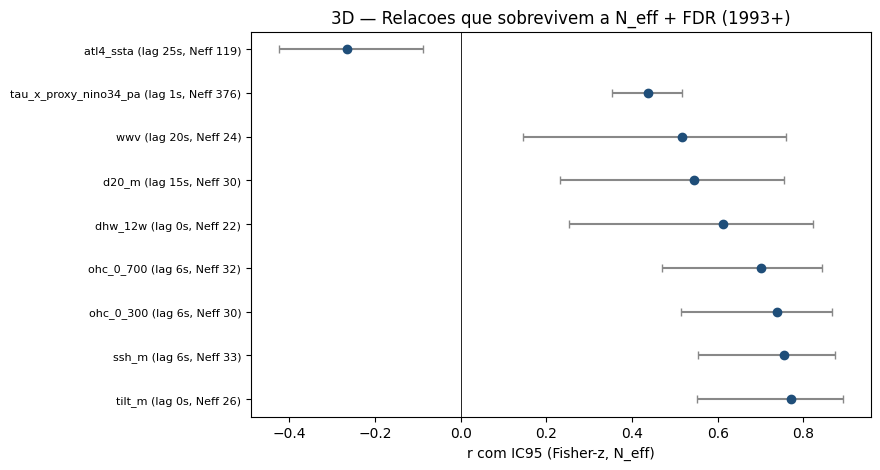

In [3]:
# Figura 3D-1: forest plot (IC95 Fisher-z) do melhor lag sobrevivente
fig, ax = plt.subplots(figsize=(8, 5))
bb = best.reset_index()
ax.errorbar(bb['r'], range(len(bb)),
            xerr=[bb['r']-bb['ic95_low'], bb['ic95_high']-bb['r']],
            fmt='o', color='#1f4e79', ecolor='#888', capsize=3)
ax.set_yticks(range(len(bb)))
ax.set_yticklabels([f"{v} (lag {l}s, Neff {n:.0f})" for v, l, n in zip(bb['variavel'], bb['lag_semanas'], bb['n_eff'])], fontsize=8)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('r com IC95 (Fisher-z, N_eff)'); ax.set_title('3D — Relacoes que sobrevivem a N_eff + FDR (1993+)')
u.save_fig(fig, 'phase3D_forest_ic95.png')
plt.show()

[figura] data/processed/figures/fase3/phase3D_mapa_lon_lag_fdr.png
[tabela] data/processed/parquet/statistics/phase3D_mapa_fdr_resumo.csv


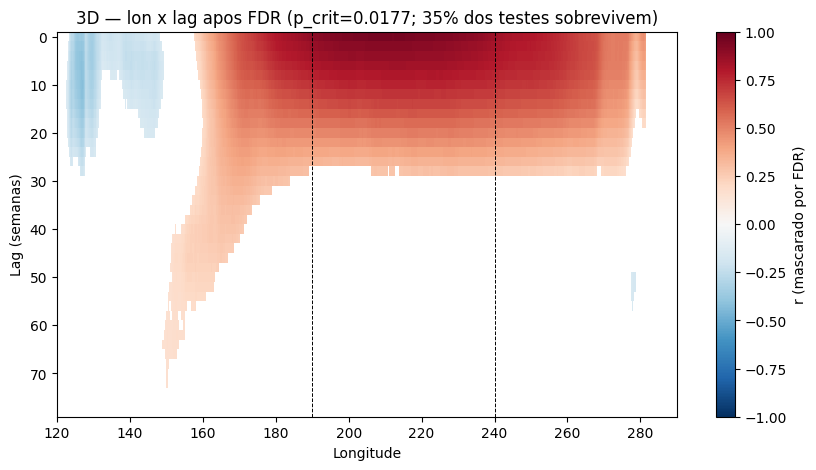

,metrica,valor
0,testes_validos,25840.000000
1,sobreviventes_fdr,9157.000000
2,pct,35.400000
3,p_critico,0.017694


In [4]:
# Mapa 3D-1: lon x lag mascarado por FDR (familia propria do mapa)
eq = u.load_eqband_weekly().loc[COMMON:]
eq_al, tgt_al = eq.align(target, join='inner', axis=0)
lags_map = list(range(0, 79, 2))
tv = tgt_al.values
R = np.full((len(lags_map), eq_al.shape[1]), np.nan)
P = np.full_like(R, np.nan)
for i, lag in enumerate(lags_map):
    shifted = eq_al.shift(lag).values
    for j in range(eq_al.shape[1]):
        x = shifted[:, j]
        m = np.isfinite(x) & np.isfinite(tv)
        if m.sum() > 100:
            r = float(np.corrcoef(x[m], tv[m])[0,1]); R[i,j] = r
            P[i,j] = correlation_p_value(r, effective_sample_size(x[m], tv[m]))
flat = P[np.isfinite(P)]
rej_map, _q = benjamini_hochberg_fdr(flat, alpha=0.05)
pcrit_map = float(flat[rej_map].max()) if rej_map.any() else float('nan')
mask = np.full_like(P, False, dtype=bool); mask[np.isfinite(P)] = rej_map
Rm = np.where(mask, R, np.nan)
lon = eq_al.columns.values
fig, ax = plt.subplots(figsize=(10, 5))
pc = ax.pcolormesh(lon, lags_map, Rm, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.axvline(190, color='k', ls='--', lw=0.7); ax.axvline(240, color='k', ls='--', lw=0.7)
ax.invert_yaxis(); ax.set_xlabel('Longitude'); ax.set_ylabel('Lag (semanas)')
pct = 100*mask.sum()/np.isfinite(P).sum()
ax.set_title(f'3D — lon x lag apos FDR (p_crit={pcrit_map:.3g}; {pct:.0f}% dos testes sobrevivem)')
fig.colorbar(pc, ax=ax, label='r (mascarado por FDR)')
u.save_fig(fig, 'phase3D_mapa_lon_lag_fdr.png')
resumo_mapa = pd.DataFrame({'metrica': ['testes_validos','sobreviventes_fdr','pct','p_critico'],
                            'valor': [int(np.isfinite(P).sum()), int(mask.sum()), round(pct,1), pcrit_map]})
u.save_table(resumo_mapa, 'phase3D_mapa_fdr_resumo.csv', index=False)
plt.show()
resumo_mapa

**Leitura do 3D.** A correção por N_eff é severa nas séries ENSO — a autocorrelação de ~6 meses (3B) reduz os graus de liberdade efetivos em uma ordem de grandeza, e é exatamente por isso que correlações aparentemente altas do 3C podem não sobreviver. O que resta após FDR + IC95 é o conjunto de relações que a Fase 3 pode defender publicamente. Regra de corte do parecer: entra apenas o que sobrevive **aqui e** no teste de estabilidade do 3E.